In [ ]:
pip install pytubefix


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 19.8 MB/s eta 0:00:00


In [ ]:
import subprocess
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import pytubefix
import torch
import torchvision
from IPython.display import  Video
from torchvision.io import read_image
from torchvision import transforms
from pytubefix import YouTube
from torchvision.transforms.functional import to_pil_image
from torchvision.utils import make_grid

In [ ]:
print("torch version : ", torch.__version__)
print("pytube version : ", pytubefix.__version__)
print("torchvision version : ", torchvision.__version__)
print("cv2 version : ", cv2.__version__)

!python --version

torch version :  2.9.0+cu126
pytube version :  10.3.5
torchvision version :  0.24.0+cu126
cv2 version :  4.12.0
Python 3.12.12


**Fetching YouTube Video Data**

For this project, we'll use a video of an interview with an Indian Olympic boxer Mary Kom. She's a legendary athlete with many achievements. Among others, she's the only boxer to ever win eight World Championship medals.


We'll load the video of her interview from YouTube. We want to put the video file in directory "data" which should be in the "project4" directory.


**Task 4.2.1: Create a variable for the video directory using pathlib syntax.**

In [ ]:
project_dir= Path("Project4")
data_dir=  "data"
video_dir= project_dir / data_dir

video_dir.mkdir(parents=True, exist_ok=True)
print(f"Project directory:{project_dir}")
print(f" video directory{video_dir}")

Project directory:<bound method Path.resolve of PosixPath('Project4')>
 video directoryProject4/data



Next we'll need to specify the URL of the YouTube video and download the video. We decided to save the video under file name video_name = "mary_kom.mp4".

In [ ]:
video_name="mary_kom.mp4"
video_url="https://www.youtube.com/watch?v=XScnCdyVbIU"
yt=YouTube(video_url)


Because downloading from YouTube doesn't always work, we wrapped the code in a try/except block.


**Task 4.2.2:  Fill in the missing code in the else part of the try/except block below. If grabbing the YouTube stream worked, we want to download the video to directory video_dir using file name video_name.**

In [ ]:
from urllib.error import HTTPError
try:
  stream = yt.streams.get_highest_resolution()
except HTTPError:
  print("Downloadable from cloud Storage")
  if not (video_dir / video_name ).exists():
     video_dir.mkdir(parents=True,exist_ok=True)
     !gcloud storage cp --no-clobber \ gs: //wqu-cv-course-datasets/mary_kom.mp4 \ $video_dir
else:
     print('Downloading form youtube...')
     stream.download(output_path=video_dir, filename=video_name)

In [ ]:
!ls -l Project4/data/

total 152328
-rw-r--r-- 1 root root 155978059 Nov 27 13:52 mary_kom.mp4



**Task 4.2.3: Create a variable for the video file path using pathlib syntax.**

In [ ]:
print(video_dir)
print(video_name)

Project4/data
mary_kom.mp4


In [ ]:
input_video= video_dir / video_name
print(input_video)
Video(input_video, width=400)

Project4/data/mary_kom.mp4



**Task 4.2.4: Fill in the missing code that defines the signature of the cut_video function. By looking at the function's doc string, you can see what the input parameters should be.**

In [ ]:
def cut_video(input_file, output_file, start_time, duration):
    """
    Cuts a portion of the video.

    :parameter input_file: Path to the input video file.
    :parameter output_file: Path to the output video file.
    :parameter start_time: Start time of the cut in seconds or in `HH:MM:SS` format.
    :parameter duration: Duration of the cut in seconds or in `HH:MM:SS` format.
    """
    command = [
        "ffmpeg",
        "-ss",
        str(start_time),
        "-i",
        input_file,
        "-t",
        str(duration),
        "-c",
        "copy",
        output_file,
    ]
    subprocess.run(command)


cut_video?


**Task 4.2.5: Create a variable for the output video file path using pathlib syntax. Let's call the file "output.mp4". It should be in the same directory as our input video file.** **bold text**

In [ ]:
output_video_name = "output.mp4"

output_video = video_dir / output_video_name

print(output_video)

Project4/data/output.mp4



**Task 4.2.6: Call the cut_video function using the input_video and output_video variables you defined in the previous tasks.**

In [ ]:
start_time = "00:00:00"  # Start at 00 seconds
duration = "00:01:00"  # Cut 1 minute

# Call cut_video function
cut_video(input_video, output_video, start_time, duration)

In [ ]:
video_caputure =cv2.VideoCapture(output_video)
if not video_caputure.isOpened():
  print("Error: Could not open video.")
else:
  frame_rate = video_caputure.get(cv2.CAP_PROP_FPS)
  frame_count = int(video_caputure.get(cv2.CAP_PROP_FRAME_COUNT))
  print(f"Frame rate: {frame_rate}")
  print(f"Total number of frames: {frame_count}")

Frame rate: 25.0
Total number of frames: 1501



**Task 4.2.8: Use the video capture variable you defined in the previous task and fetch the first frame. The rest of the code will display the frame.**

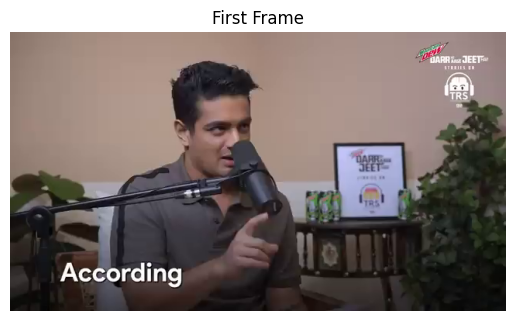

In [ ]:
ret, first_frame = video_caputure.read()

if ret:
    plt.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
    plt.title("First Frame")
    plt.axis("off")
    plt.show()
else:
    print("Error: Could not read frame.")


**Task 4.2.9: Get the shape of the frame and the number of channels by calling the shape attribute on the first_frame variable.**

In [ ]:
height, width, channel = first_frame.shape

print("frames height : ", height)
print("frames width : ", width)
print("frames channel : ", channel)

frames height :  360
frames width :  640
frames channel :  3



**Task 4.2.10: Create a directory path for the extracted frames using the pathlib syntax. This path should be a directory called extracted_frames which should be in video_dir.**

In [ ]:
frames_dir = video_dir /"extracted_frames"

frames_dir.mkdir(exist_ok=True)
print(frames_dir)

Project4/data/extracted_frames



**Task 4.2.11: Fill in the missing code below that saves every fifth frame from the video. **

In [ ]:
interval = 5
frame_count=0
print("Start extracting individual frames...")
while True:
   #read next frame from the video capture
   ret , frame = video_caputure.read()
   if not ret:
      print ("Finished baby!")
      break


   if frame_count % interval == 0:
      frame_path = frames_dir  / f"frame_{frame_count}.jpg"
      cv2.imwrite(frame_path, frame)

   frame_count += 1
video_caputure.release()

Start extracting individual frames...
Finished baby!


**Task 4.2.12: Compute the number of frames we've extracted by using iterdir() method on the frames_dir path. That'll give you a generator that you need to covert to list before usinglen.**

In [ ]:
n_extraced_frames = len(list(frames_dir.iterdir()))

print(f"We saved {n_extraced_frames} frames.")

We saved 300 frames.



To conclude this lesson, let's display some sample frames that we extracted. The function display_sample_images below that'll display a grid of sample frames is the same as the one we used in the previous project.

**Task 4.2.13: Fill in the missing code in display_sample_images function.**

In [ ]:
def display_sample_images(dir_path, sample=5):
    image_list = []
    images = sorted(dir_path.iterdir())
    if images:
        sample_images = images[:sample]
        for sample_image in sample_images:
            image = read_image(str(sample_image))

            # Define resizing transformation that resizes to 240 x 240
            resize_transform = transforms.Resize((240,240))
            # Resize image by using `resize_transform`
            image = resize_transform(image)
            image_list.append(image)
    grid = make_grid(image_list, nrow=5)
    image = to_pil_image(grid)
    return image


display_sample_images?


**Task 4.2.14: Use display_sample_images function to display 20 of the frames that we extracted.**

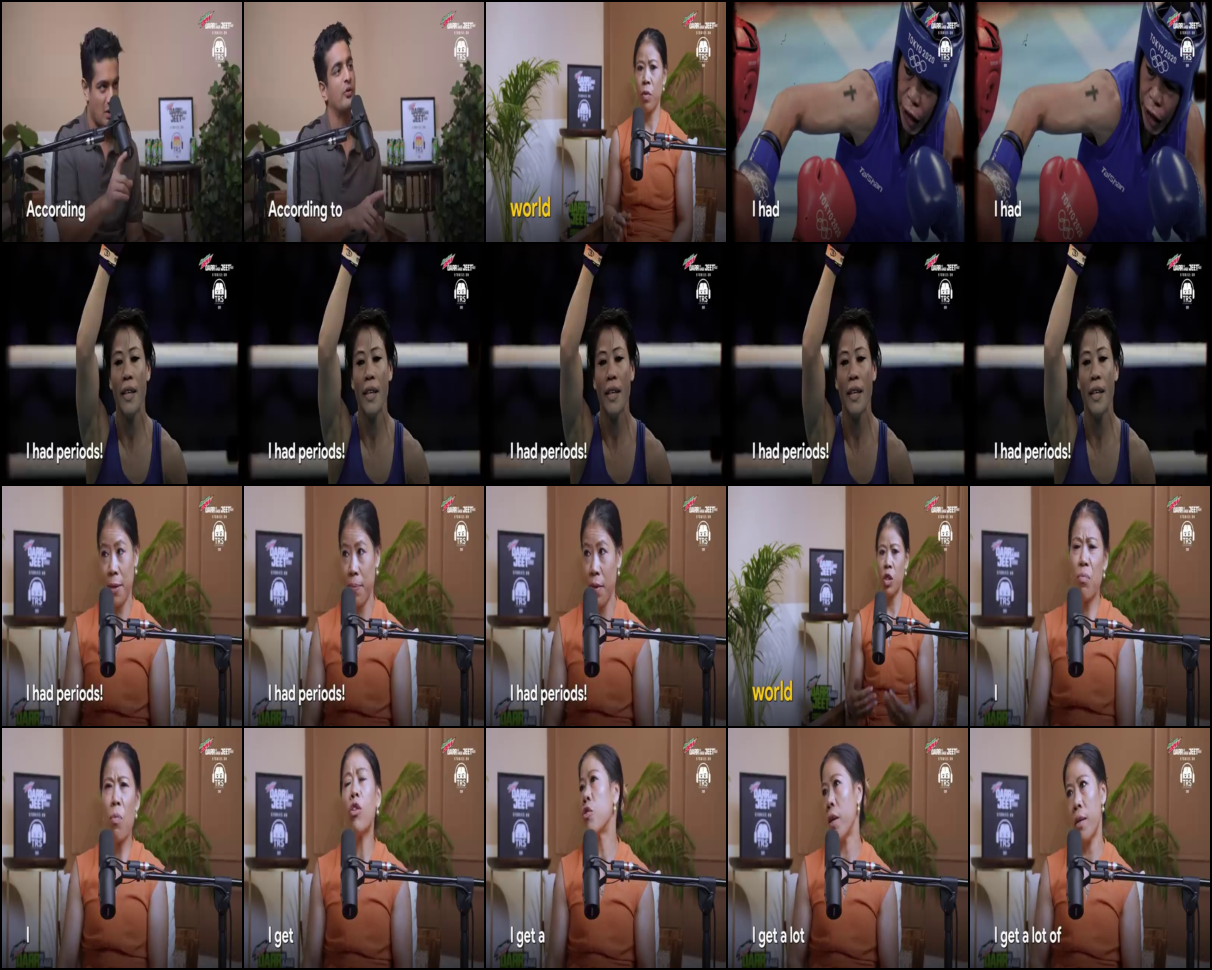

In [ ]:
# Call function `display_sample_images` on `frames_dir`
display_sample_images(frames_dir,sample=20)